#Goal

To perform data preprocessing and Transformation for the ETL project

Source:https://github.com/cgre23/etl-dataset/blob/main/big_tech_stock_prices.txt

#Part-1

###Environment Setup


In [140]:
import numpy as np
import pandas as pd
import warnings
from datetime import date , timedelta
import re
import os

import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
sns.set_style('whitegrid')


###1.1 Data Extraction

In [141]:
def extract_csv(file_path, encoding='utf-8'):
  """
  Reuseable Csv extraction function with error handling

  parameters:
  -----------
  file_path: str
    The path to the csv file
  encoding: str
      File encoding (default: 'utf-8')

  Returns:
  -------
  pd.Dataframe or None
  """

  try:
    df = pd.read_csv(file_path ,sep=',' ,encoding=encoding)
    print("File extracted sucessfully!")
    print(f"Shape : {df.shape}")
    return df
  except FileNotFoundError:
    print(f"Error: File not found {file_path}")
    return None
  except Exception as e:
    print(f"Error Extracting {file_path }: {str(e)}")
    return None

print("=" * 60)
print("EXTRACTING DATA FROM CSV FILES")
print("=" * 60)

stock_market_raw = extract_csv('/content/Data/big_tech_stock_prices.txt')

print("\n" + "=" * 60)
print("EXTRACTION COMPLETE")
print("=" * 60)


EXTRACTING DATA FROM CSV FILES
File extracted sucessfully!
Shape : (45088, 8)

EXTRACTION COMPLETE


###1.2 Data Profiling

In [142]:

def profile_data(df , name):
  """
  Genarate a quick profile report for a dataframe
  profile report contains:
    -shape (rows x columns)
    -data types
    -memory usage
    -first 3 rows of the dataset
    -basic mathematical statistics
  """
  print(f"\n{'=' * 60}")
  print(f"Profile Report for {name}")
  print('=' * 60)
  print(f"\nShape : {df.shape[0]:,} rows x {df.shape[1]} columns")
  print(f"\nColumns and datatypes:")
  print(df.dtypes)
  print(f"\nMemory Usage: {df.memory_usage(deep = True).sum() / 1023:.2f} KB")
  print(f"\nFirst 3 rows:")
  print(df.head(3))
  print(f"\nBasic Statistics:")
  print(df.describe(include='all'))

profile_data(stock_market_raw , 'stock_market_raw')




Profile Report for stock_market_raw

Shape : 45,088 rows x 8 columns

Columns and datatypes:
stock_symbol     object
date             object
open            float64
high            float64
low             float64
close           float64
adj_close       float64
volume            int64
dtype: object

Memory Usage: 7048.82 KB

First 3 rows:
  stock_symbol        date      open      high       low     close  adj_close  \
0         AAPL  2010-01-04  7.622500  7.660714  7.585000  7.643214   6.515213   
1         AAPL  2010-01-05  7.664286  7.699643  7.616071  7.656429   6.526476   
2         AAPL  2010-01-06  7.656429  7.686786  7.526786  7.534643   6.422664   

      volume  
0  493729600  
1  601904800  
2  552160000  

Basic Statistics:
       stock_symbol        date          open          high           low  \
count         45088       45088  45088.000000  45088.000000  45088.000000   
unique           14        3287           NaN           NaN           NaN   
top            AAPL  202

###1.3 Data Validation

In [143]:
def validate_extract(df , expected_columns , min_rows=100, name="Dataset"):
  """
  Validate extracted data against business rules
  parameters:
  -----------
    -df DataFrame
    -expected columns int
    -min_rows int

  Report Contains:
  --------------
    -dataset
    -issues
    -row_count
    -column_count
    -extra columns
    -null_summary
  """

  report = {
      'dataset': name,
      'passed': True,
      'issues': []
  }

  # check if Dataframe is none
  if df is None:
      report['passed'] = False
      report['issues'].append("Dataframe is None")
      return report

  # check row count
  if len(df) < min_rows:
      report['passed'] = False
      report['issues'].append(f"Insufficient rows: {len(df)} < {min_rows}")

  # check missing columns
  missing_cols = set(expected_columns) - set(df.columns)
  if missing_cols:
      report['passed'] = False
      report['issues'].append(f"Missing columns: {missing_cols}")

  # check extra columns
  extra_cols = set(df.columns) - set(expected_columns)
  if extra_cols:
      report['issues'].append(f"Extra columns Found: {extra_cols}")

  # calculate null percentages
  null_pcts = (df.isnull().sum() / len(df) * 100).round(2)
  high_null_cols = null_pcts[null_pcts > 10].to_dict()

  if high_null_cols:
      report['issues'].append(f"High null % : {high_null_cols}")

  # report details
  report['row_count'] = len(df)
  report['column_count'] = len(df.columns)
  report['null_summary'] = null_pcts.to_dict()

  return report

print("\n" + "="*60)
print("VALIDATION REPORT")
print("="*60)

stock_validation = validate_extract(
    stock_market_raw,
    ['stock_symbol','date','open','high','low','close','adj_close','volume'],
    min_rows=100,
    name='orders_dataset'
)


print(f"\nDataset: {stock_validation['dataset']}")
print(f"Status : {'Passed' if stock_validation['passed'] else 'Failed'}")
print(f"Row Count : {stock_validation.get('row_count')}")
print(f"Column Count : {stock_validation.get('column_count')}")

if stock_validation['issues']:
    print("Issues:")
    for issue in stock_validation['issues']:
        print(f" - {issue}")

print("=" * 60)




VALIDATION REPORT

Dataset: orders_dataset
Status : Passed
Row Count : 45088
Column Count : 8


###Add Random Null values to the Dataset

In [144]:

def add_random_nulls(df, missing_fraction=0.05, random_state=None):
    """
    Randomly insert null values into a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset
    missing_fraction : float
        Fraction of total values to replace with NaN (e.g., 0.05 = 5%)
    random_state : int or None
        Seed for reproducibility

    Returns
    -------
    pd.DataFrame
    """

    df_copy = df.copy()

    if random_state is not None:
        np.random.seed(random_state)

    total_cells = df_copy.size
    num_missing = int(total_cells * missing_fraction)

    # Generate random row and column indices
    rows = np.random.randint(0, df_copy.shape[0], num_missing)
    cols = np.random.randint(0, df_copy.shape[1], num_missing)

    for r, c in zip(rows, cols):
        df_copy.iat[r, c] = np.nan

    return df_copy

stock_market_raw = add_random_nulls(stock_market_raw,0.10)

###1.4 Data Quality Report

In [145]:
def data_quality_report(df , name="Dataset"):
  """
  Comphresive data quality assesment

  Returns a detailed quality report including:
  - Null counts and Percentages
  - Duplicate rows
  - Unique value counts
  - Data type issues
  """

  print(f"\n{'=' * 60}")
  print(f"Data Quality Report : {name}")
  print("=" * 60)

  # Basic Info
  print(f"\nBasic Info:")
  print(f" Total Rows: {len(df):,}")
  print(f" Total Columnnst: {len(df.columns)}")

  #Null analysis
  print(f"\nNull Values: ")
  null_summary = pd.DataFrame({
      'Column' :df.columns,
      'Null_Count': df.isnull().sum().values,
      'Null_Pct' : (df.isnull().sum().values / len(df) * 100).round(2)
  })

  null_summary = null_summary[null_summary['Null_Count'] > 0].sort_values('Null_Pct', ascending=False)
  if len(null_summary) > 0:
        print(null_summary.to_string(index=False))
  else:
      print("No null values found!")

  #Duplicatie Analysis
  print(f"\n Duplicates:")
  total_duplicates = df.duplicated().sum()
  print(f"Total Duplicates: {total_duplicates}")
  if total_duplicates > 0:
    print(f"Percentage of Duplicates: {total_duplicates / len(df) * 100:.2f}%")

  #Unique Values
  print(f"\nUnique Value Counts:")
  unique_summary = pd.DataFrame({
      'Column': df.columns,
      'Unique_Values': [df[col].nunique() for col in df.columns],
      'Unique_Values_Pct': [(df[col].nunique() / len(df)) * 100 for col in df.columns]
  })

  unique_summary['Unique_Values_Pct'] = unique_summary['Unique_Values_Pct'].round(2)
  print(unique_summary.to_string(index=False))

  #data types
  print(f"\nData Types:")
  print(df.dtypes.value_counts())

  return {
      'total_rows': len(df),
      'total_nulls': df.isnull().sum().sum(),
      'total_duplicates': total_duplicates
  }

factory_data_report = data_quality_report(stock_market_raw , 'stock_market_raw')




Data Quality Report : stock_market_raw

Basic Info:
 Total Rows: 45,088
 Total Columnnst: 8

Null Values: 
      Column  Null_Count  Null_Pct
         low        4354      9.66
stock_symbol        4325      9.59
      volume        4301      9.54
   adj_close        4295      9.53
        high        4281      9.49
       close        4268      9.47
        date        4239      9.40
        open        4220      9.36

 Duplicates:
Total Duplicates: 0

Unique Value Counts:
      Column  Unique_Values  Unique_Values_Pct
stock_symbol             14               0.03
        date           3286               7.29
        open          27694              61.42
        high          27870              61.81
         low          27753              61.55
       close          28603              63.44
   adj_close          37609              83.41
      volume          39523              87.66

Data Types:
float64    6
object     2
Name: count, dtype: int64


###1.5 Visualizing Data Quality Issues


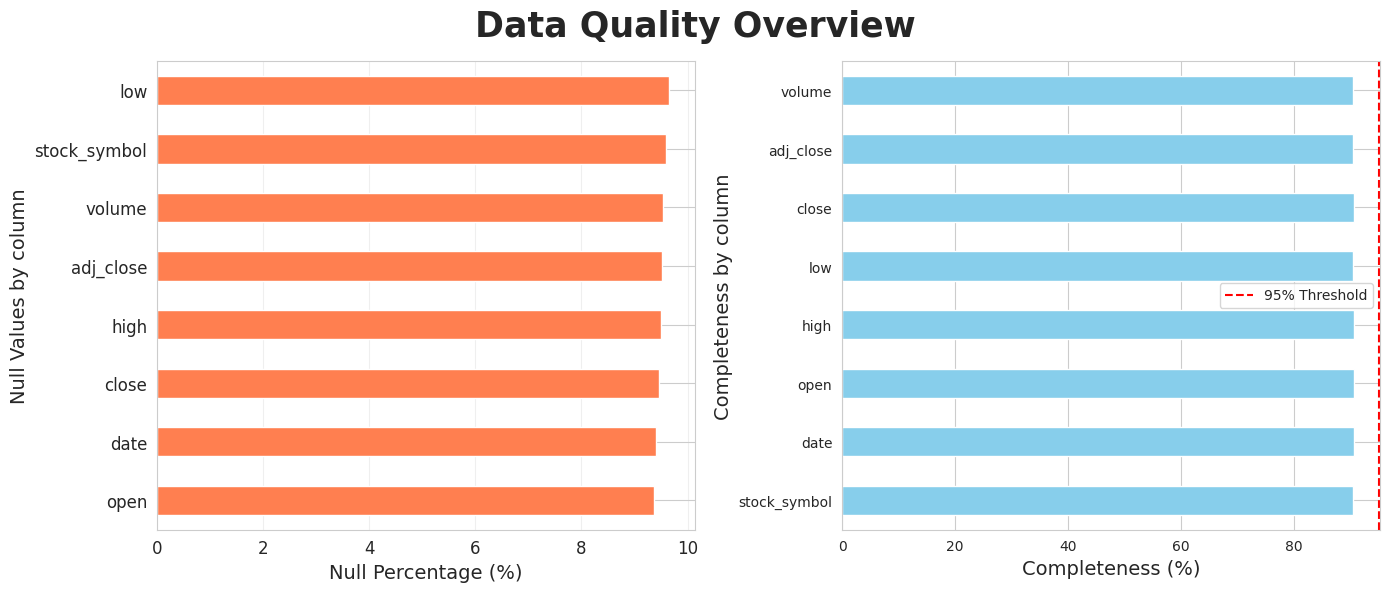

In [146]:
def visualize_data_quality(df , title="Data Quality Overview"):
  """
  Create Visualiztion (Bar Chart) for data quality issues
  """

  fig, axes = plt.subplots(1 , 2 , figsize=(14 , 6))
  fig.suptitle(title , fontsize=25, fontweight='bold')

  #Null percenatges
  null_pcts = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
  null_pcts.plot(kind='barh' , ax=axes[0] , color='coral')
  axes[0].set_xlabel('Null Percentage (%)', fontsize=14)
  axes[0].set_ylabel('Null Values by column', fontsize=14)
  axes[0].tick_params(axis='both', which='major', labelsize=12)
  axes[0].grid(axis='x' , alpha = 0.3)

  #data Completeness

  completeness = (1 - df.isnull().sum() / len(df)) * 100
  completeness.plot(kind='barh' , ax=axes[1] , color='skyblue')
  axes[1].set_xlabel('Completeness (%)', fontsize=14)
  axes[1].set_ylabel('Completeness by column', fontsize=14)
  axes[1].tick_params(axis='both', which='major', labelsize=12)
  axes[1].axvline(95, color='red', linestyle='--', label='95% Threshold')

  axes[1].tick_params(axis='both', labelsize=10)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

#Visulaise the data
visualize_data_quality(stock_market_raw)




###

###1.6 Handling Null Values

In [147]:
stock_market_raw_copy = stock_market_raw.copy()

stock_market_raw_copy = stock_market_raw_copy.sort_values(by="date")

print("=" * 60)
print("\nHandling Null Values")
print("=" * 60)

print(f"\nBefore - Nulls: {stock_market_raw_copy.isnull().sum().sum()}")

stock_market_raw_copy.ffill(inplace=True)

print(f"\nAfter - Nulls: {stock_market_raw_copy.isnull().sum().sum()}")


Handling Null Values

Before - Nulls: 34283

After - Nulls: 0


###1.7 DataType Conversion

In [148]:
'''
This Part converts all the data types to the correct format
'''

print("="*70)
print("DATA TYPE CONVERSIONS")
print("="*70)

print("\nBefore:")
print(stock_market_raw_copy.dtypes)

#Convert Date to Datetime
stock_market_raw_copy['date'] = pd.to_datetime(stock_market_raw_copy['date'])

#convert strings to integers and floats
stock_market_raw_copy[['open', 'high', 'low', 'close', 'adj_close']] = stock_market_raw_copy[['open', 'high', 'low', 'close', 'adj_close']].astype(float)
stock_market_raw_copy['volume'] = stock_market_raw_copy['volume'].astype(int)

print("\nAfter")
print(stock_market_raw_copy.dtypes)
print("\n" + "="*70)

DATA TYPE CONVERSIONS

Before:
stock_symbol     object
date             object
open            float64
high            float64
low             float64
close           float64
adj_close       float64
volume          float64
dtype: object

After
stock_symbol            object
date            datetime64[ns]
open                   float64
high                   float64
low                    float64
close                  float64
adj_close              float64
volume                   int64
dtype: object



###1.8 Data Aggreagation and Grouping

In [149]:
'''
Data Aggregation and Grouping Performed
---------------------------------------

1. Stock Summary (Grouped by stock_symbol)
   ---------------------------------------
   a. open   → mean (average opening price)
   b. close  → mean (average closing price)
   c. high   → max  (highest price observed)
   d. low    → min  (lowest price observed)
   e. volume → sum  (total traded volume)

2. Monthly Price Trends (Grouped by stock_symbol + month)
   -------------------------------------------------------
   a. open   → mean
   b. close  → mean
   c. high   → max
   d. low    → min
   e. volume → sum

3. Volatility Calculation
   ----------------------
   a. daily_range = high - low
   b. average daily_range computed per stock_symbol
      → represents average price volatility.

4. Daily Returns
   --------------
   a. daily_return = (close - open) / open
   b. mean daily_return calculated per stock_symbol
      → represents average daily return of the stock.
'''
print("="*70)
print("AGGREGATION & GROUPING EXAMPLES")
print("="*70)

#stock summary
print("="*70)
print("Stock Summary")
print("="*70)
stock_summary = stock_market_raw_copy.groupby("stock_symbol").agg({
    "open": "mean",
    "close" : "mean",
    "high":"max",
    "low":"min",
    "volume": "sum"
})
print(stock_summary)

#monthly price trends
print("="*70)
print("Monthly Price Trends")
print("="*70)
monthly_prices = stock_market_raw_copy.groupby(
    ["stock_symbol", pd.Grouper(key="date", freq="M")]
).agg({
    "open": "mean",
    "close" : "mean",
    "high":"max",
    "low":"min",
    "volume": "sum"
})
print(monthly_prices.head())

#Daily Price range
print("="*70)
print("Daily Price Range")
print("="*70)
stock_market_raw_copy['daily_range'] = stock_market_raw_copy['high'] - stock_market_raw_copy['low']
volatility_summary = stock_market_raw_copy.groupby("stock_symbol")["daily_range"].mean()
print(volatility_summary)

#Daily Returns
print("="*70)
print("Daily Returns")
print("="*70)
stock_market_raw["daily_return"] = (
    stock_market_raw["close"] - stock_market_raw["open"]
) / stock_market_raw["open"]

returns = stock_market_raw.groupby("stock_symbol")["daily_return"].mean()
print(returns)

print("=" * 70)

AGGREGATION & GROUPING EXAMPLES
Stock Summary
                    open       close        high       low        volume
stock_symbol                                                            
AAPL           59.675709   57.681972  685.260010  1.646667  728163359677
ADBE          169.406736  170.743408  699.539978  1.300000   36521193564
AMZN           64.323779   63.143230  584.219971  1.217333  269140736230
CRM           101.622798  102.262511  666.429993  1.333333   47719986625
CSCO           42.828221   42.058285  553.489990  1.177333  117118507507
GOOGL          57.148597   56.480010  685.260010  1.445333  195279006033
IBM           138.769272  138.111952  679.479980  1.384000   43501168866
INTC           45.641617   45.719652  694.890015  1.306667  129891315533
META          139.320187  138.882148  663.669983  1.996667   91254923580
MSFT           96.844561   96.961394  630.239990  1.606000  133609817462
NFLX          170.445056  171.358160  700.989990  1.300000   78976688351
NVDA 

##1.9 Save Cleaned Data

In [150]:
os.makedirs('/content/Data/cleaned', exist_ok=True)

try:
  stock_market_raw_copy.to_csv("Data/cleaned/stock_market_trends_clean.csv")
  print("="*70)
  print("CLEANED DATA SAVED")
  print("="*70)
  print(f"Airlines: {len(stock_market_raw_copy):,}")
except Exception as e:
  print(f"Error saving cleaned data: {str(e)}")


CLEANED DATA SAVED
Airlines: 45,088


##Part-2 Data Transformation

###2.1  Setup

In [151]:
# Core libraries
import pandas as pd
import numpy as np
import sqlite3
import logging
import warnings
from datetime import datetime, timedelta
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

def load_dataset(file_path):
  try:
    df = pd.read_csv(file_path)
    print("Dataset Loaded Sucessfully")
    return df
  except Exception as e:
    print(f"Error loading dataset: {str(e)}")
    return None

def fix_data_type(df):
  try:
    df['date'] = pd.to_datetime(df['date'])
    df[['open', 'high', 'low', 'close', 'adj_close']] = stock_market_raw_copy[['open', 'high', 'low', 'close', 'adj_close']].astype(float)
    df['volume'] = stock_market_raw_copy['volume'].astype(int)
    print("Datatype Converted sucessfully")
  except Exception as e:
    print(f"Error fixing data types: {str(e)}")
    return None

stock_market_clean = load_dataset("Data/cleaned/stock_market_trends_clean.csv")
fix_data_type(stock_market_clean)

✅ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
Dataset Loaded Sucessfully
Datatype Converted sucessfully


###2.2 Concatenation

In [152]:
'''
Concatenation on the basis of year and Quarter
'''
print("="*70)
print("CONCATENATION")
print("="*70)

print("\n📂 Use Case: Combining Quarterly Files")
stock_market_clean['year'] = stock_market_clean['date'].dt.year
stock_market_clean['quarter'] = stock_market_clean['date'].dt.quarter


stock_market_clean['year_quarter'] = (
    stock_market_clean['year'].astype(str) +
    '_Q' + stock_market_clean['quarter'].astype(str)
)

groups = {
    name : df.copy()
    for name, df in stock_market_clean.groupby('year_quarter')
}

print("Available groups:")
print(list(groups.keys())[:10])


print("\n" + "="*70)
print(stock_market_clean.head())


CONCATENATION

📂 Use Case: Combining Quarterly Files
Available groups:
['2010_Q1', '2010_Q2', '2010_Q3', '2010_Q4', '2011_Q1', '2011_Q2', '2011_Q3', '2011_Q4', '2012_Q1', '2012_Q2']

   Unnamed: 0 stock_symbol       date      open      high       low     close  \
0           0         AAPL 2010-01-04  7.622500  7.660714  7.585000  7.643214   
1       19626          IBM 2010-01-04  7.664286  7.699643  7.616071  7.656429   
2        3271         ADBE 2010-01-04  7.656429  7.686786  7.526786  7.534643   
3       13084         CSCO 2010-01-04  7.562500  7.571429  7.466071  7.520714   
4       22897         INTC 2010-01-04  7.510714  7.571429  7.466429  7.570714   

   adj_close     volume  daily_range  year  quarter year_quarter  
0   6.515213  493729600     0.075714  2010        1      2010_Q1  
1   6.526476  601904800     2.026764  2010        1      2010_Q1  
2   6.422664  552160000     0.649997  2010        1      2010_Q1  
3   6.410790  477131200     0.830000  2010        1      2010_

###2.3 Pivoting

In [153]:
'''
Pivoting Table on the basis of Year and Quarter along with the companies
'''
print("="*70)
print("PIVOTING")
print("="*70)

print("\nPivot - Quarterly Summary along with companies")

stock_market_clean['daily_return'] = (
    ((stock_market_clean['close'] - stock_market_clean['open'])
    / stock_market_clean['open']) * 100
)

pivot_returns = stock_market_clean.pivot_table(
    index='year_quarter',
    columns='stock_symbol',
    values='daily_return',
    aggfunc='mean'
)

print(pivot_returns.head())

PIVOTING

Pivot - Quarterly Summary along with companies
stock_symbol       AAPL      ADBE       AMZN        CRM       CSCO      GOOGL  \
year_quarter                                                                    
2010_Q1       43.181469  0.240850  28.512592  14.387690  12.780672  11.179745   
2010_Q2        9.525006  1.258351   2.093386   0.526581   9.054803  -0.555848   
2010_Q3       11.111379 -2.456944  11.954724   0.556963  14.274695  -2.096323   
2010_Q4        9.917164 -1.897770   1.261625   9.840299   1.722687   9.566228   
2011_Q1        9.531585  7.819334  28.548296  15.146126   5.681343  20.069228   

stock_symbol        IBM       INTC  META       MSFT       NFLX       NVDA  \
year_quarter                                                                
2010_Q1       12.204264  27.476600   NaN  -1.436895  22.743883   0.021962   
2010_Q2        8.990737   8.209081   NaN   6.826683   2.362662  12.410019   
2010_Q3       -6.621503   2.583513   NaN  25.855528  -0.311416  21.

###2.4 Feature Engineering

In [154]:
'''
Following are the Features we will extract
-----------------------------------------
    1.Daily Returns %
    2.Industry Range
    3.Close position in range
    4.Day Trend
    5. 5- Day Trend
'''

print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

features_df = stock_market_clean.copy()
print("\n1. Daily Returns Columns")
features_df['daily_return'] = ((features_df['close'] - features_df['open']) / features_df['open']) * 100
print(f"created Daily Returns %")
print(f"Average Daily Returns : {features_df['daily_return'].mean():.2f} %")

print("\n2. Industry Range")
features_df['industry_range'] = features_df['high'] - features_df['low']
print(f"created Industry Range")
print(f"Average Industry Range : {features_df['industry_range'].mean():.2f}")

print("\n3. Close Position in Range")
features_df['close_in_range'] = (
    (features_df['close'] - features_df['low']) /
    (features_df['high'] - features_df['low'])
) * 100

print(f"created Close Position in Range %")
print(f"Average Close Position in Range : {features_df['close_in_range'].mean():.2f} %")

print("\n4. 5 Day Trend")
features_df['5_day_trend'] = (
    features_df
    .groupby('stock_symbol')['close']
    .transform(lambda x: x.rolling(5).mean())
)

print(f"created 5 Day Trend")
print("\nExample: 5-Day Rolling Trend Calculation")

example = features_df[features_df['stock_symbol'] == 'GOOGL'][['date','close','5_day_trend']].head(7)

print(example)
print("\nExplanation:")
print("The 5_day_trend is the rolling average of the last 5 closing prices.")
print("First 4 rows are NaN because 5 days of data are required.")
print("Example for Day5:")
print("(Day1 + Day2 + Day3 + Day4 + Day5) / 5")

FEATURE ENGINEERING

1. Daily Returns Columns
created Daily Returns %
Average Daily Returns : 17.44 %

2. Industry Range
created Industry Range
Average Industry Range : 2.04

3. Close Position in Range
created Close Position in Range %
Average Close Position in Range : -inf %

4. 5 Day Trend
created 5 Day Trend

Example: 5-Day Rolling Trend Calculation
         date      close  5_day_trend
9  2010-01-04   7.354643          NaN
22 2010-01-05   6.858929          NaN
45 2010-01-08   8.030000          NaN
65 2010-01-11   8.569643          NaN
72 2010-01-12  26.190001    11.400643
80 2010-01-13  22.035000    14.336715
99 2010-01-14   8.718214    14.708572

Explanation:
The 5_day_trend is the rolling average of the last 5 closing prices.
First 4 rows are NaN because 5 days of data are required.
Example for Day5:
(Day1 + Day2 + Day3 + Day4 + Day5) / 5


###2.5 Business Rule Validation

In [155]:
def apply_businees_rules(df):
  '''
  Following are the Business Rules
  --------------------------------
      1.Price must be positive
      2. High Must be highest
      3.Low must be lowest
      4. Volume mus tbe non negative
      5. Duplicate Stock change rule
      6. Weekend Trading rule
      7. Extreme daily traiding rule

  ---------------------------------
      returns:
        a Validation report of the violatons
  '''
  df = df.copy()

  validation_results = {}
  print("="*70)
  print("BUSINESS RULE VALIDATION")
  print("="*70)

  #1.Price must be positive
  validation_results['invalid_price'] = df[
      (df[['open' , 'high', 'low', 'close']] <= 0).any(axis=1)
      ]
   #2. high must be highest
  validation_results['invalid_high'] = df[
      (df['high'] < df['open']) |
      (df['high'] < df['close']) |
      (df['high'] < df['low'])
  ]

  #3. Low must be lowest
  validation_results['invalid_low'] = df[
      (df['low'] > df['open']) |
      (df['low'] > df['close'])
  ]

  #4. Volume must be non-negative
  validation_results['invalid_volume'] = df[
      df['volume'] < 0
  ]

  #5. Duplicate stock-date records
  duplicates = df.duplicated(
    subset=['stock_symbol','date']
  )
  validation_results['duplicate_records'] = df[duplicates]

  # 6 Weekend trading rule
  df['day_of_week'] = df['date'].dt.dayofweek
  validation_results['weekend_trades'] = df[
      df['day_of_week'] >= 5
  ]

  # 7 Extreme daily return rule
  df['daily_return'] = (
      (df['close'] - df['open'])
      / df['open']
  ) * 100

  validation_results['extreme_moves'] = df[
      abs(df['daily_return']) > 40
  ]
  print("\nValidation Summary")
  print("-"*70)

  for rule, df in validation_results.items():
      print(f"{rule:25s} : {len(df):,} violations")

  print("\nTotal Rows Checked:", len(stock_market_clean))
  print("="*70)

apply_businees_rules(features_df)


BUSINESS RULE VALIDATION

Validation Summary
----------------------------------------------------------------------
invalid_price             : 0 violations
invalid_high              : 7,180 violations
invalid_low               : 5,747 violations
invalid_volume            : 0 violations
duplicate_records         : 8,059 violations
weekend_trades            : 0 violations
extreme_moves             : 5,057 violations

Total Rows Checked: 45088


In [156]:
print(features_df.head())

   Unnamed: 0 stock_symbol       date      open      high       low     close  \
0           0         AAPL 2010-01-04  7.622500  7.660714  7.585000  7.643214   
1       19626          IBM 2010-01-04  7.664286  7.699643  7.616071  7.656429   
2        3271         ADBE 2010-01-04  7.656429  7.686786  7.526786  7.534643   
3       13084         CSCO 2010-01-04  7.562500  7.571429  7.466071  7.520714   
4       22897         INTC 2010-01-04  7.510714  7.571429  7.466429  7.570714   

   adj_close     volume  daily_range  year  quarter year_quarter  \
0   6.515213  493729600     0.075714  2010        1      2010_Q1   
1   6.526476  601904800     2.026764  2010        1      2010_Q1   
2   6.422664  552160000     0.649997  2010        1      2010_Q1   
3   6.410790  477131200     0.830000  2010        1      2010_Q1   
4   6.453412  447610800     0.300001  2010        1      2010_Q1   

   daily_return  industry_range  close_in_range  5_day_trend  
0      0.271748        0.075714       76.

###2.6 Loading to CSV

In [157]:
'''
In this part we will load all the data to a csv file
'''
import os

print("="*70)
print("EXPORTING DATASETS TO CSV")
print("="*70)

# Create output directory
os.makedirs("output", exist_ok=True)

# Remove unwanted index column if present
if 'Unnamed: 0' in features_df.columns:
    features_df = features_df.drop(columns=['Unnamed: 0'])


# 1 Export full transformed dataset

print("\nExport 1: Full transformed dataset")

full_output = "output/stock_market_transformed.csv"

features_df.to_csv(full_output, index=False)

print(f"Saved: {full_output}")
print(f"Rows: {len(features_df):,}")
print(f"Columns: {len(features_df.columns)}")
print(f"File size: {os.path.getsize(full_output)/1024:.2f} KB")


# 2 Export quarterly summary dataset
print("\nExport 2: Quarterly stock summary")

quarter_summary = (
    features_df
    .groupby(['stock_symbol','year','quarter'])
    .agg({
        'close':'mean',
        'volume':'sum',
        'daily_return':'mean'
    })
    .reset_index()
)

quarter_output = "output/quarterly_stock_summary.csv"

quarter_summary.to_csv(quarter_output, index=False)

print(f"Saved: {quarter_output}")
print(f"Rows: {len(quarter_summary):,}")
print(f"Columns: {len(quarter_summary.columns)}")
print(f"File size: {os.path.getsize(quarter_output)/1024:.2f} KB")

print("\nData export completed successfully.")
print("="*70)

EXPORTING DATASETS TO CSV

Export 1: Full transformed dataset
Saved: output/stock_market_transformed.csv
Rows: 45,088
Columns: 16
File size: 7660.66 KB

Export 2: Quarterly stock summary
Saved: output/quarterly_stock_summary.csv
Rows: 732
Columns: 6
File size: 42.51 KB

Data export completed successfully.


###2.7 load to SQLlite Database

In [158]:
'''
In this we will load the dataset into the following databases
------------------------------------------------------------
    1.Main Fact Database (stock_price_fact)
    2.Stock Dimesion (stock_dim)
    3.Quarterly Summary Table (quarterly_summary)
    4.Yearly Summary Table (yearly_summary)
'''
import sqlite3
import pandas as pd

print("="*70)
print("LOADING DATA TO SQLITE DATABASE")
print("="*70)


# Create database connection

db_path = "output/stock_market_etl.db"
conn = sqlite3.connect(db_path)

print(f"\nConnected to database: {db_path}")

print("\nLoading tables into database...")


# 1 Main fact table (full dataset)

features_df.to_sql(
    "stock_prices_fact",
    conn,
    if_exists="replace",
    index=False
)

print(f"Loaded stock_prices_fact: {len(features_df):,} rows")


# 2 Stock dimension table
stock_dim = (
    features_df[['stock_symbol']]
    .drop_duplicates()
)

stock_dim.to_sql(
    "stock_dim",
    conn,
    if_exists="replace",
    index=False
)

print(f"Loaded stock_dim: {len(stock_dim):,} rows")

# 3 Quarterly summary table
quarter_summary = (
    features_df
    .groupby(['stock_symbol','year','quarter'])
    .agg({
        'close':'mean',
        'volume':'sum',
        'daily_return':'mean'
    })
    .reset_index()
)

quarter_summary.to_sql(
    "quarterly_summary",
    conn,
    if_exists="replace",
    index=False
)

print(f"Loaded quarterly_summary: {len(quarter_summary):,} rows")


# 4 Yearly stock summary
year_summary = (
    features_df
    .groupby(['stock_symbol','year'])
    .agg({
        'close':'mean',
        'volume':'sum',
        'daily_return':'mean'
    })
    .reset_index()
)

year_summary.to_sql(
    "yearly_summary",
    conn,
    if_exists="replace",
    index=False
)

print(f"Loaded yearly_summary: {len(year_summary):,} rows")


# Verify tables
print("\nDatabase Tables:")

tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(tables_query, conn)

print(tables)

print("\nDatabase loading completed.")
print("="*70)



LOADING DATA TO SQLITE DATABASE

Connected to database: output/stock_market_etl.db

Loading tables into database...
Loaded stock_prices_fact: 45,088 rows
Loaded stock_dim: 14 rows
Loaded quarterly_summary: 732 rows
Loaded yearly_summary: 194 rows

Database Tables:
                name
0  stock_prices_fact
1          stock_dim
2  quarterly_summary
3     yearly_summary

Database loading completed.


###2.8 Create Indexes for better performance

In [159]:
'''
In this we will create Indexes for
----------------------
  1. stock_price_fact (Main Full Dataset table)
  2. Quarterly Summary
  3. Yearly Summary
'''

print("\n" + "="*70)
print("CREATING DATABASE INDEXES")
print("="*70)

cursor = conn.cursor()

#Indexes for stock_prices_fact
cursor.execute(
    """
    CREATE INDEX idx_stock_symbol ON stock_prices_fact (stock_symbol);
""")

cursor.execute(
    """
    CREATE INDEX idx_date ON stock_prices_fact (date);
    """
)

cursor.execute(
    """
    Create INDEX if not exists idx_stock_symbol_date ON stock_prices_fact (stock_symbol, date);
    """
)

#Index for Quarterly Summary
cursor.execute(
    """
    CREATE INDEX idx_stock_symbol_year_quarter ON quarterly_summary (stock_symbol);
    """
)

cursor.execute(
    """
    CREATE INDEX idx_year_quarter ON quarterly_summary (year);
    """
)

#Index for Yearly Summary
cursor.execute(
    """
    CREATE INDEX idx_stock_symbol_year ON yearly_summary (stock_symbol);
    """)
cursor.execute(
    """
    CREATE INDEX IF NOT EXISTS idx_year_year
    ON yearly_summary(year);
    """
)

# Commit changes
conn.commit()
print("Indexes created successfully")


# Verify indexes
print("\nDatabase Indexes:")

indexes = pd.read_sql_query(
    "SELECT name, tbl_name FROM sqlite_master WHERE type='index';",
    conn
)

print(indexes)

print("="*70)



CREATING DATABASE INDEXES
Indexes created successfully

Database Indexes:
                            name           tbl_name
0               idx_stock_symbol  stock_prices_fact
1                       idx_date  stock_prices_fact
2          idx_stock_symbol_date  stock_prices_fact
3  idx_stock_symbol_year_quarter  quarterly_summary
4               idx_year_quarter  quarterly_summary
5          idx_stock_symbol_year     yearly_summary
6                  idx_year_year     yearly_summary


###2.9 Verifying Database using Queries

In [160]:
'''
In this we will Verify
 ---------------------
  1. Check Row count
  2.Preview Stock Data
  3.Verify Stock Dimension
  4.yearly stock performance
  5.top traded stock
  5.highest average returns
'''
print("="*70)
print("DATABASE VERIFICATION QUERIES")
print("="*70)


# 1 Check row counts


print("\n1. Table Row Counts")

tables = [
    "stock_prices_fact",
    "stock_dim",
    "quarterly_summary",
    "yearly_summary"
]

for table in tables:
    query = f"SELECT COUNT(*) as row_count FROM {table}"
    result = pd.read_sql_query(query, conn)
    print(f"{table:25s}: {result['row_count'][0]:,} rows")


# 2 Preview stock data

print("\n2. Sample Stock Records")

query = """
SELECT stock_symbol, date, open, close, volume
FROM stock_prices_fact
ORDER BY date
LIMIT 5;
"""

print(pd.read_sql_query(query, conn))


# 3 Verify stock dimension
print("\n3. Available Stocks")

query = """
SELECT stock_symbol
FROM stock_dim
ORDER BY stock_symbol;
"""

# 4 Quarterly summary check
print("\n4. Quarterly Summary Example")

query = """
SELECT stock_symbol, year, quarter,
       ROUND(close,2) as avg_close,
       volume as total_volume
FROM quarterly_summary
LIMIT 5;
"""

print(pd.read_sql_query(query, conn))

# 5 Yearly performance check
print("\n5. Yearly Stock Performance")

query = """
SELECT stock_symbol,
       year,
       ROUND(close,2) as avg_price,
       volume as yearly_volume
FROM yearly_summary
ORDER BY year
LIMIT 10;
"""

print(pd.read_sql_query(query, conn))

# 6 Top traded stocks
print("\n6. Top Traded Stocks")

query = """
SELECT stock_symbol,
       SUM(volume) as total_volume
FROM stock_prices_fact
GROUP BY stock_symbol
ORDER BY total_volume DESC
LIMIT 5;
"""

print(pd.read_sql_query(query, conn))


# 7. Highest Average Returns
print("\n7. Highest Average Returns")

query = """
SELECT stock_symbol,
       ROUND(AVG(daily_return),2) as avg_return
FROM stock_prices_fact
GROUP BY stock_symbol
ORDER BY avg_return DESC
LIMIT 5;
print(pd.read_sql_query(query, conn))
"""

print("\nDatabase verification completed")
print("="*70)

DATABASE VERIFICATION QUERIES

1. Table Row Counts
stock_prices_fact        : 45,088 rows
stock_dim                : 14 rows
quarterly_summary        : 732 rows
yearly_summary           : 194 rows

2. Sample Stock Records
  stock_symbol                 date      open     close     volume
0         AAPL  2010-01-04 00:00:00  7.622500  7.643214  493729600
1          IBM  2010-01-04 00:00:00  7.664286  7.656429  601904800
2         ADBE  2010-01-04 00:00:00  7.656429  7.534643  552160000
3         CSCO  2010-01-04 00:00:00  7.562500  7.520714  477131200
4         INTC  2010-01-04 00:00:00  7.510714  7.570714  447610800

3. Available Stocks

4. Quarterly Summary Example
  stock_symbol  year  quarter  avg_close  total_volume
0         AAPL  2010        1      16.17   25889622633
1         AAPL  2010        2      22.42   17235268520
2         AAPL  2010        3      42.12    7541853400
3         AAPL  2010        4      74.60    7762541066
4         AAPL  2011        1     104.82    299612

###2.10 Logging and Error Handling

In [161]:
# Setup logging
import logging
from datetime import datetime

# Create logs directory
os.makedirs('logs', exist_ok=True)

# Configure logging
log_filename = f'logs/etl_pipeline_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename),
        logging.StreamHandler()  # Also print to console
    ]
)

logger = logging.getLogger('ETL_Pipeline')

print("="*70)
print("ERROR HANDLING & LOGGING DEMONSTRATION")
print("="*70)

def safe_extract(file_path):
    """
    Extract with error handling and logging
    """
    try:
        logger.info(f"Attempting to extract: {file_path}")
        df = pd.read_csv(file_path)
        logger.info(f"Successfully extracted {len(df)} rows from {file_path}")
        return df
    except FileNotFoundError:
        logger.error(f"File not found: {file_path}")
        return None
    except pd.errors.EmptyDataError:
        logger.error(f"Empty file: {file_path}")
        return None
    except Exception as e:
        logger.error(f"Unexpected error extracting {file_path}: {str(e)}")
        return None

def safe_load_to_db(df, table_name, conn, if_exists='replace'):
    """
    Load to database with error handling and retry logic
    """
    max_retries = 3
    retry_count = 0

    while retry_count < max_retries:
        try:
            logger.info(f"Attempting to load {len(df)} rows to table '{table_name}' (Attempt {retry_count + 1}/{max_retries})")
            df.to_sql(table_name, conn, if_exists=if_exists, index=False)
            logger.info(f"Successfully loaded to {table_name}")
            return True
        except sqlite3.OperationalError as e:
            retry_count += 1
            logger.warning(f"Database locked, retrying... ({retry_count}/{max_retries})")
            if retry_count >= max_retries:
                logger.error(f"Failed to load {table_name} after {max_retries} attempts: {str(e)}")
                return False
        except Exception as e:
            logger.error(f"Error loading to {table_name}: {str(e)}")
            return False

    return False

# Test logging
logger.info("=" * 50)
logger.info("ETL Pipeline Logging Demo Started")
logger.info("=" * 50)

# Test error handling
print("\n🧪 Testing error handling...")
result = safe_extract('data/nonexistent_file.csv')  # This will fail
result = safe_extract('data/cleaned/customers_clean.csv')  # This will succeed

logger.info("ETL Pipeline Logging Demo Completed")

print(f"\n✅ Log file created: {log_filename}")
print("\n" + "="*70)

ERROR:ETL_Pipeline:File not found: data/nonexistent_file.csv
ERROR:ETL_Pipeline:File not found: data/cleaned/customers_clean.csv


ERROR HANDLING & LOGGING DEMONSTRATION

🧪 Testing error handling...

✅ Log file created: logs/etl_pipeline_20260308_071332.log

